# Mini Project 1 — Analysis Notebook

**Your name:** Ashlesha Hadkar 
**Dataset:** Week 6 / `KCC Data /combined_kcc_3states_en.csv` (merged Maharashtra, Karnataka, Uttar Pradesh KCC exports; produced by `combine_translate_kcc.py`).
**Date:**  6/05/2026

This notebook has four sections. Work through them in order. Each section has instructions and a code cell to fill in. Add markdown cells to explain your thinking as you go — that writing is part of the assignment.

When you're done, publish this notebook to your GitHub repository and submit the URL to Canvas.

In [1]:
# Setup — run this cell first
# If any package is missing, it will install automatically
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["pandas", "plotly", "kaleido", "nbformat"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

import pandas as pd
import plotly.express as px
import plotly.io as pio

# GitHub cannot run Plotly JS — embed a PNG copy in each cell output
pio.renderers.default = "plotly_mimetype+png"

print("Setup complete.")

Setup complete.


---

## Section 1 — Overview

Before writing any code, fill in this section. A good Overview tells anyone reading your notebook — including a future employer — what the analysis is about before they see a single chart.

**Original source:** data.gov.in
https://api.data.gov.in/resource/cef25fe2-9231-4128-8aec-2c948fedd43f

**Data accessed from:** State-level KCC CSV folders under `Week 6/KCC Data /` (Maharashtra, Karnataka, Uttar Pradesh), combined with `combine_translate_kcc.py`, which also adds `KccAns_en` for translated answers when translation has been run.

**Why this dataset**

Farmer support systems like KCC are designed to  bring agricultural expertise directly to rural communities, but design intent and ground-level reality are not always the same thing — and that gap is a core HCD question. This dataset is a lens for examining 
who gets helped and who doesn't, how underserved communities interact with government-built technology, and whether a public support system is actually reaching the people it was built for.

**Three analytical questions:**

1. Which types of queries dominate each month, and how does the mix change across the year?
2. Are queries tagged to the right QueryType? A mismatch audit.
3. What share of queries are for Agronomic / Crop Advisory support, how does the topic breakdown differ by state, and is demand growing?

**What a practitioner would do with these findings:** *(One sentence. Who uses this, and for what?)*

---

## Section 2 — Data Profile

Load your dataset and get a basic picture of what's in it. Answer these questions in a markdown cell below your code:

- How many rows and columns does your dataset have?
- What does each column represent?
- Are there any obvious data quality issues (missing values, unexpected types, inconsistent formatting)?
- Which column or columns will your analysis focus on, and why?

In [2]:
# Load combined KCC CSV (built by combine_translate_kcc.py → KCC Data /combined_kcc_3states_en.csv)
from pathlib import Path

filename = 'combined_kcc_3states_en.csv'
abs_csv = Path('/Users/ashleshahadkar/Documents/HCDE 530 Repository/Week 6/KCC Data /combined_kcc_3states_en.csv')
kcc_dir = Path('KCC Data ')

# Absolute-first path lookup avoids failures when notebook cwd changes.
candidates = [
    abs_csv,
    Path.cwd() / kcc_dir / filename,
    Path.cwd() / Path('Week 6') / kcc_dir / filename,
    Path.cwd().parent / Path('Week 6') / kcc_dir / filename,
    Path.cwd().parent.parent / Path('Week 6') / kcc_dir / filename,
]
# This code finds the path to the CSV file for the KCC CSVs.
csv_path = next((path for path in candidates if path.exists()), None)
if csv_path is None:
    searched = '\n'.join(str(path) for path in candidates)
    raise FileNotFoundError(
        f"Could not find '{filename}'. Run from Week 6/: python3 combine_translate_kcc.py (or --resume). Checked:\n{searched}"
    )
# This code reads the CSV file for the KCC CSVs.
df = pd.read_csv(csv_path, encoding='utf-8-sig', low_memory=False)

# Drop Maharashtra 2025 rows so all three states cover the same 2022-2024 window
df = df[~((df['StateName'].astype(str).str.strip() == 'MAHARASHTRA') & (df['year'] == 2025))]
df = df.reset_index(drop=True)

df['QueryType_clean'] = df['QueryType'].astype(str).str.strip()

print(f'Loaded from: {csv_path}')
print(df.shape)
df.head()

Loaded from: /Users/ashleshahadkar/Documents/HCDE 530 Repository/Week 6/KCC Data /combined_kcc_3states_en.csv
(5400, 18)


,BlockName,Category,CreatedOn,Crop,DistrictName,KCCCallID,KccAns,QueryText,QueryType,Season,Sector,StateName,day,month,year,_source_file,KccAns_en,QueryType_clean
0,MADHA,Sugar and Starch Crops,2022-04-24T17:01:29.06,Sugarcane (Noble Cane),SOLAPUR,1197635,ऊस पिकासाठी-१२ ६१ ०० ६० ग्रॅम + मायक्रोला ३० म...,FARMER ASKED ABOUT FERTILIZER SPRAY ON SUGARCA...,Fertilizer Use and Availability,NaN,AGRICULTURE,MAHARASHTRA,24,4,2022,Maharashtra/2022/apr.csv,For sugarcane crop- 12 61 00 60 gm + micro wit...,Fertilizer Use and Availability
1,AUNDHA NAGNATH,Condiments and Spices,2022-04-24T17:02:24.237,Turmeric,HINGOLI,1197668,हवामान विभागाच्या अंदाजानुसार आपल्या औंढा-नागन...,Farmer asked query on Weather,Weather,NaN,HORTICULTURE,MAHARASHTRA,24,4,2022,Maharashtra/2022/apr.csv,According to the forecast of the Meteorologica...,Weather
2,JAMKHED,Others,2022-04-25T09:01:04.307,Others,AHMADNAGAR,1200438,⦁\tप्रधानमंत्री किसान सन्मान निधी योजना संबंधी...,Farmer asked about PM Kisan Sanman Nidhi Yojan...,Government Schemes,NaN,AGRICULTURE,MAHARASHTRA,25,4,2022,Maharashtra/2022/apr.csv,⦁ For more information regarding Prime Ministe...,Government Schemes
3,PAUNI,Others,2022-04-25T09:05:43.497,Others,BHANDARA,1200546,पी एम किसान साठी तुमच्या जवळील तहसील ऑफिस ला ज...,FARMER ASKED ABOUT PM KISAN ?,Government Schemes,NaN,AGRICULTURE,MAHARASHTRA,25,4,2022,Maharashtra/2022/apr.csv,For PM Kisan visit your nearest tehsil office ...,Government Schemes
4,MANGALVEDHE,Others,2022-04-25T09:16:57.56,Others,SOLAPUR,1200431,"हवामान विभागाच्या अंदाजानुसार,आपल्या तालुक्यात...",Farmer asked query on Weather,Weather,NaN,AGRICULTURE,MAHARASHTRA,25,4,2022,Maharashtra/2022/apr.csv,According to the forecast of Meteorological De...,Weather


In [3]:
# Check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BlockName        5400 non-null   object 
 1   Category         5400 non-null   object 
 2   CreatedOn        5400 non-null   object 
 3   Crop             5400 non-null   object 
 4   DistrictName     5400 non-null   object 
 5   KCCCallID        5400 non-null   int64  
 6   KccAns           5390 non-null   object 
 7   QueryText        5400 non-null   object 
 8   QueryType        5400 non-null   object 
 9   Season           0 non-null      float64
 10  Sector           5400 non-null   object 
 11  StateName        5400 non-null   object 
 12  day              5400 non-null   int64  
 13  month            5400 non-null   int64  
 14  year             5400 non-null   int64  
 15  _source_file     5400 non-null   object 
 16  KccAns_en        5390 non-null   object 
 17  QueryType_clea

In [4]:
# Summary statistics for numeric columns
df.describe()

,KCCCallID,Season,day,month,year
count,5.400000e+03,0.0,5400.000000,5400.000000,5400.000000
mean,3.125479e+06,NaN,14.819074,6.500000,2023.000000
std,2.079564e+06,NaN,8.347631,2.500232,0.816572
min,5.557060e+05,NaN,1.000000,3.000000,2022.000000
25%,1.337276e+06,NaN,8.000000,4.000000,2022.000000
50%,2.589199e+06,NaN,14.000000,6.500000,2023.000000
75%,4.927158e+06,NaN,23.000000,9.000000,2024.000000
max,7.139959e+06,NaN,31.000000,10.000000,2024.000000


**Your data profile notes:**  
*(Replace this with your observations — what's in the data, what you noticed, what questions it raises.)*

---

## Section 3 — Analysis

Answer your three research questions using pandas. Each question should have:

1. A markdown cell stating the question
2. A code cell with the analysis
3. A markdown cell with your interpretation — what does the result mean?

You may need to clean or reshape the data before you can answer a question. That's normal — document what you did and why.

### Q1. What query types are farmers asking across Maharashtra, Karnataka, and Uttar Pradesh?

Overall distribution of query types across all three states:


,QueryType,count,pct
0,Weather,2317,42.907407
1,Government Schemes,1100,20.370370
2,Plant Protection,637,11.796296
3,Market Information,273,5.055556
4,Nutrient Management,208,3.851852
5,Cultural Practices,183,3.388889
6,Fertilizer Use and Availability,146,2.703704
7,Weed Management,100,1.851852
8,Varieties,67,1.240741
9,Water Management,66,1.222222


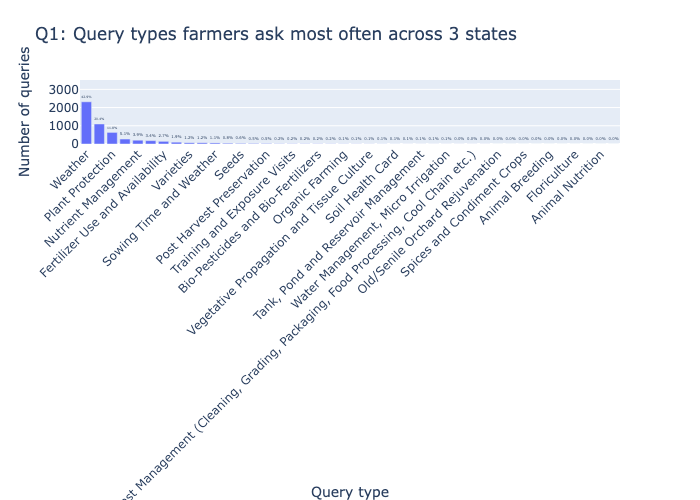

In [5]:
# Q1: Overall query-type distribution across Maharashtra, Karnataka, and Uttar Pradesh
q1 = df.copy()
q1['QueryType_clean'] = q1['QueryType'].astype(str).str.strip()

q1_dist = (
    q1['QueryType_clean']
    .value_counts()
    .reset_index()
)
q1_dist.columns = ['QueryType', 'count']
q1_dist['pct'] = 100 * q1_dist['count'] / q1_dist['count'].sum()

print('Overall distribution of query types across all three states:')
display(q1_dist)

fig_q1 = px.bar(
    q1_dist,
    x='QueryType',
    y='count',
    title='Q1: Query types farmers ask most often across 3 states',
    labels={'count': 'Number of queries', 'QueryType': 'Query type'},
    text=q1_dist['pct'].round(1).astype(str) + '%',
)
fig_q1.update_layout(xaxis_tickangle=-45)
fig_q1.update_traces(textposition='outside')
fig_q1.show()

**Interpretation**

Weather, government schemes, plant protection and market information are the top categories with highest number of requests for information. 

**Observation**

1. Weather is the most frequent query type at 20.4%, accounting for roughly 1 in 5 calls across all three states. It exceeds the next category, Government Schemes, by nearly 9 percentage points, and is higher than Plant Protection, Nutrient Management, and Fertilizer Use combined.

2. The volume indicates that farmers are regularly turning to KCC to support crop decisions affected by weather — sowing timing, input application, harvest planning. This is not incidental usage; it is a consistent and dominant pattern in the data.

3. KCC is structured as a human-staffed advisory service. Weather queries at this scale suggest a mismatch between the system's design capacity and the nature of what farmers are actually asking. A call agent responding to a weather query is likely relaying publicly available forecast information rather than providing specialized agronomic guidance, which is what the service is intended to deliver.

 ### Question 2:  For each state separately, how have all query types trended from 2022 to 2024 — are certain issues increasing, decreasing, or stable over time?**


### Q2. How do query-type trends change by state from 2022 to 2024?

This compares yearly query counts by type for each state (Karnataka, Maharashtra, and Uttar Pradesh).

Q2 trend table (2022-2024, top query types + Other):


,StateName,year,QueryType_grouped,count
6,KARNATAKA,2022,Weather,319
1,KARNATAKA,2022,Government Schemes,88
2,KARNATAKA,2022,Market Information,53
5,KARNATAKA,2022,Plant Protection,43
3,KARNATAKA,2022,Nutrient Management,41
...,...,...,...,...
71,UTTAR PRADESH,2024,Cultural Practices,31
75,UTTAR PRADESH,2024,Nutrient Management,26
72,UTTAR PRADESH,2024,Fertilizer Use and Availability,11
79,UTTAR PRADESH,2024,Weed Management,11


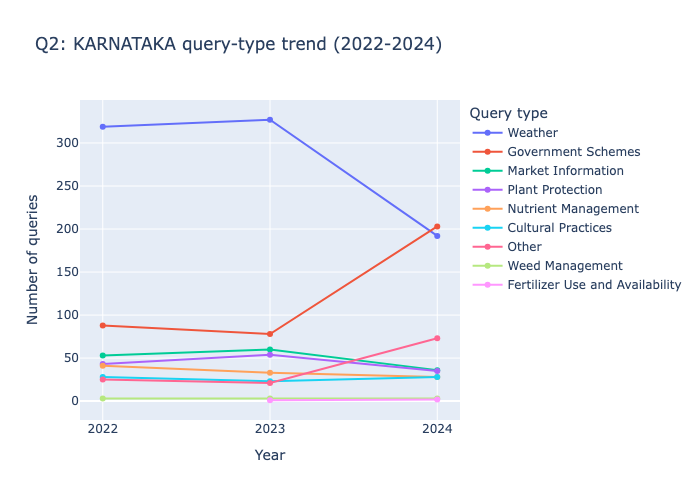

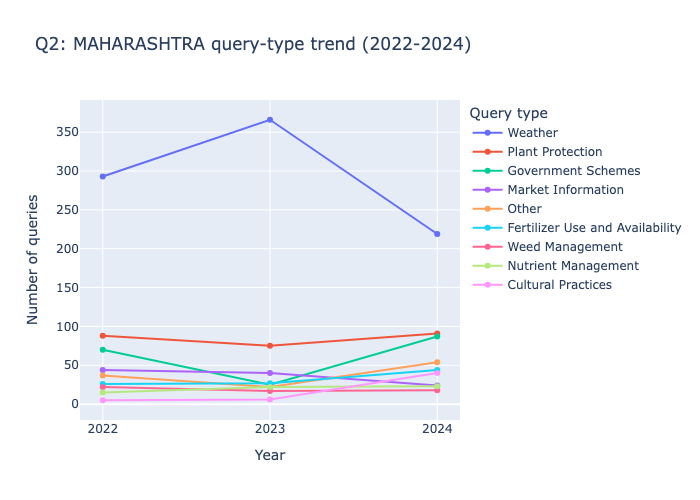

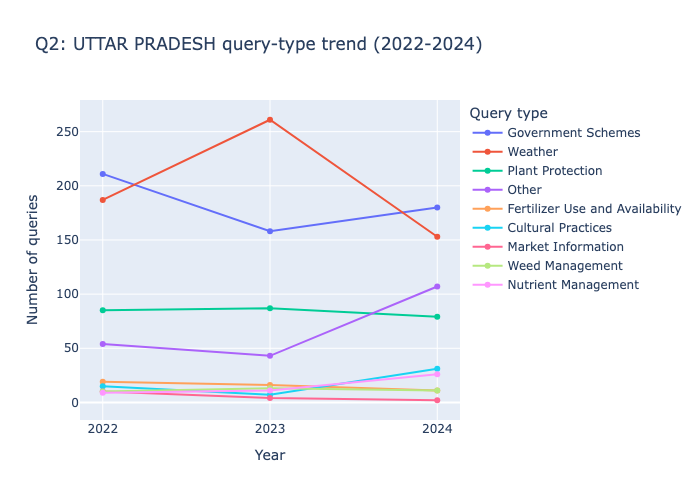

In [6]:
# Q2: State-wise query-type trends (2022-2024), with top types + Other for readability
q2 = df.copy()
q2['StateName'] = q2['StateName'].astype(str).str.strip()
q2['QueryType_clean'] = q2['QueryType'].astype(str).str.strip()
q2 = q2[q2['year'].between(2022, 2024)].copy()

top_types_q2 = q2['QueryType_clean'].value_counts().head(8).index.tolist()
q2['QueryType_grouped'] = q2['QueryType_clean'].where(q2['QueryType_clean'].isin(top_types_q2), 'Other')

q2_trend = (
    q2.groupby(['StateName', 'year', 'QueryType_grouped'])
    .size()
    .reset_index(name='count')
    .sort_values(['StateName', 'year', 'count'], ascending=[True, True, False])
)

print('Q2 trend table (2022-2024, top query types + Other):')
display(q2_trend)

for state in sorted(q2_trend['StateName'].unique()):
    state_data = q2_trend[q2_trend['StateName'] == state]
    fig_state = px.line(
        state_data,
        x='year',
        y='count',
        color='QueryType_grouped',
        markers=True,
        title=f'Q2: {state} query-type trend (2022-2024)',
        labels={'year': 'Year', 'count': 'Number of queries', 'QueryType_grouped': 'Query type'},
    )
    fig_state.update_layout(xaxis=dict(dtick=1), legend_title='Query type')
    fig_state.show()

**Interpretation for Q2:** 

Detailed Interpretation : 

**Karnataka:**

Government Schemes surged from 88 queries (2022) to 203 (2024) — more than doubling. This likely reflects new government programs being announced or increasing farmer awareness of KCC as a helpline for scheme information.
Weather queries dropped from 319 to 192 — the single biggest decline. This could mean farmers found alternative weather information sources (apps, local media) or that weather events were less disruptive in 2024.
Plant Protection and Market Information stayed flat or declined slightly, suggesting stable but not growing demand for those services.


**Maharashtra:**

Weather was dominant but declining (366 in 2023 down to 219 in 2024), mirroring the Karnataka pattern.

1. Plant Protection remained consistently high (~75–91 per year) — Maharashtra has the most stable demand for pest/disease help, which aligns with its diverse cropping (brinjal, chillies, cotton).

2. Cultural Practices (a category not well defined) jumped sharply from 5–6 (2022–23) to 40 (2024). This is unusual and may reflect reclassification changes rather than a true demand shift.

3. Government Schemes spiked in 2024 (25 to 87), similar to Karnataka's pattern.

**Uttar Pradesh:**

1. Government Schemes was the top category in all three years, unlike the other two states where Weather led. This suggests UP farmers use KCC primarily for scheme/subsidy guidance rather than weather.

2. Weather declined from 261 (2023) to 153 (2024) — same downward trend as the other states.

3. Market Information nearly disappeared (10 to 2) — farmers may be using mandi apps or other digital tools instead.

**Overall Observation**
Across all three states, Weather queries are declining while Government Schemes demand is rising sharply. This suggests a shift in how farmers use KCC — from real-time weather updates (possibly now handled by apps) toward navigating government programs. Maharashtra shows the strongest demand for technical farming support (Plant Protection), while Uttar Pradesh relies on KCC primarily for administrative/scheme guidance.



**Cultural Practices categorization audit (targeted check):**

This diagnostic checks rows currently tagged as `Cultural Practices` and infers an expected category from query keywords. Rows where expected category is not Cultural Practices are flagged as potential misclassification.

Cultural Practices rows checked: 183
Potentially misclassified rows: 145 (79.2%)


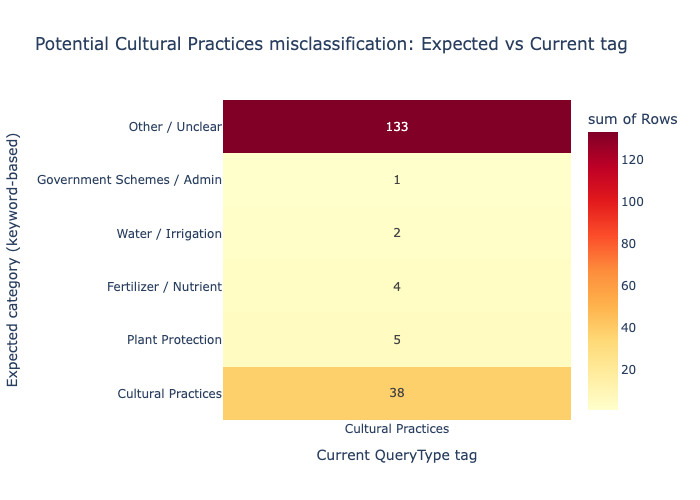


Sample flagged rows:


,StateName,DistrictName,Crop,QueryText,expected_category
66,MAHARASHTRA,KOLHAPUR,Brinjal,FARMER ASKED ABOUT INFORMATION OF BRINJAL CROP ?,Other / Unclear
317,MAHARASHTRA,PUNE,Brinjal,FARMER ASKED ABOUT VARITIES OF BRIJAL ?,Other / Unclear
766,MAHARASHTRA,AHMADNAGAR,Pumpkin,farmer ask about duration of pumpkin crop,Other / Unclear
872,MAHARASHTRA,NAGPUR,Pigeon pea (red gram/arhar/tur),FARMER ASKED ABOUT HELPLINE NO OF KRUSHI VIDYA...,Other / Unclear
1003,MAHARASHTRA,AHMADNAGAR,Sorghum (Jowar/Great Millet),FARMER ASKED ABOUT SOEING TIME OF JOWAR ?,Other / Unclear
1219,MAHARASHTRA,JALGAON,Banana,Asked about cultural practices in custard apple?,Other / Unclear
1310,MAHARASHTRA,DHULE,Brinjal,farmer ask about information about mulching pa...,Other / Unclear
1433,MAHARASHTRA,SOLAPUR,Banana,FARMER ASKED ABOUT RIPENING OF BANANA FRUITS?,Other / Unclear
1439,MAHARASHTRA,SOLAPUR,Soybean (bhat),FARMER ASKED ABOUT YIELD OF SOYABEAN CROP ?,Other / Unclear
1484,MAHARASHTRA,SOLAPUR,Soybean (bhat),FARMER ASKED ABOUT CULTURAL PRACTICES IN SOYBE...,Other / Unclear


In [7]:
# Cultural Practices misclassification audit
import re

cp = df[df['QueryType_clean'] == 'Cultural Practices'].copy()
cp['query_lower'] = cp['QueryText'].astype(str).str.lower()

def infer_expected_category(text):
    if re.search(r'scheme|yojana|subsid|pm[- ]?kisan|insurance|credit|loan|kcc|registration|portal', text):
        return 'Government Schemes / Admin'
    if re.search(r'pest|insect|worm|caterpillar|disease|blight|rot|fung|spray|pesticide', text):
        return 'Plant Protection'
    if re.search(r'fertili|urea|dap|npk|potash|manure|nutrient|micronutrient|zinc', text):
        return 'Fertilizer / Nutrient'
    if re.search(r'irrigat|water|drip|sprinkler|canal|moisture', text):
        return 'Water / Irrigation'
    if re.search(r'market|price|rate|mandi|sell|buyer|msp', text):
        return 'Market / Price'
    if re.search(r'seed|variet|sowing|spacing|pruning|nursery|transplant|cultivation|harvest', text):
        return 'Cultural Practices'
    return 'Other / Unclear'

cp['expected_category'] = cp['query_lower'].apply(infer_expected_category)
cp['current_tag'] = 'Cultural Practices'
cp['potential_misclassified'] = cp['expected_category'] != 'Cultural Practices'

total_cp = len(cp)
flagged_count = int(cp['potential_misclassified'].sum())
print(f'Cultural Practices rows checked: {total_cp}')
print(f'Potentially misclassified rows: {flagged_count} ({100*flagged_count/max(total_cp,1):.1f}%)')

expected_order = [
    'Cultural Practices',
    'Plant Protection',
    'Fertilizer / Nutrient',
    'Water / Irrigation',
    'Market / Price',
    'Government Schemes / Admin',
    'Other / Unclear',
]

heat = (
    cp.groupby(['expected_category', 'current_tag'])
    .size()
    .reset_index(name='count')
)
heat['expected_category'] = pd.Categorical(heat['expected_category'], categories=expected_order, ordered=True)
heat = heat.sort_values('expected_category')

fig_cp = px.density_heatmap(
    heat,
    x='current_tag',
    y='expected_category',
    z='count',
    color_continuous_scale='YlOrRd',
    text_auto=True,
    title='Potential Cultural Practices misclassification: Expected vs Current tag',
    labels={'current_tag': 'Current QueryType tag', 'expected_category': 'Expected category (keyword-based)', 'count': 'Rows'},
)
fig_cp.update_layout(yaxis_title='Expected category (keyword-based)', xaxis_title='Current QueryType tag')
fig_cp.show()

flagged_samples = cp[cp['potential_misclassified']].copy()
show_cols = ['StateName', 'DistrictName', 'Crop', 'QueryText', 'expected_category']
print('\nSample flagged rows:')
display(flagged_samples[show_cols].head(15))

### Q3. Which districts have the lowest call volume — and what are those farmers asking about?

**Interpretation for Q3:**  
*(What does low volume potentially mean for service access? How are top vs bottom districts different in topic demand?)*

Bottom 5 districts by call volume:


,district_label,count
55,RAIGARH (MAHARASHTRA),1
56,RATNAGIRI (MAHARASHTRA),1
64,9999 (UTTAR PRADESH),1
19,KODAGU (KARNATAKA),2
52,PALGHAR (MAHARASHTRA),2



Top 5 districts by call volume:


,district_label,count
11,CHITRADURGA (KARNATAKA),257
63,YEVATMAL (MAHARASHTRA),183
43,JALGAON (MAHARASHTRA),166
60,SOLAPUR (MAHARASHTRA),162
5,BELLARY (KARNATAKA),161


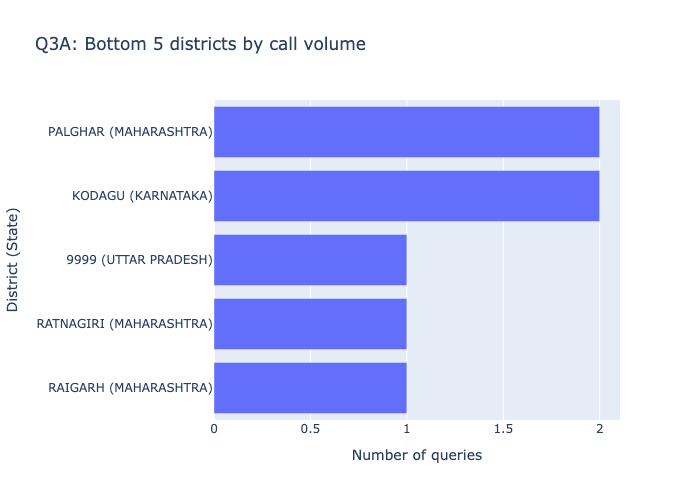

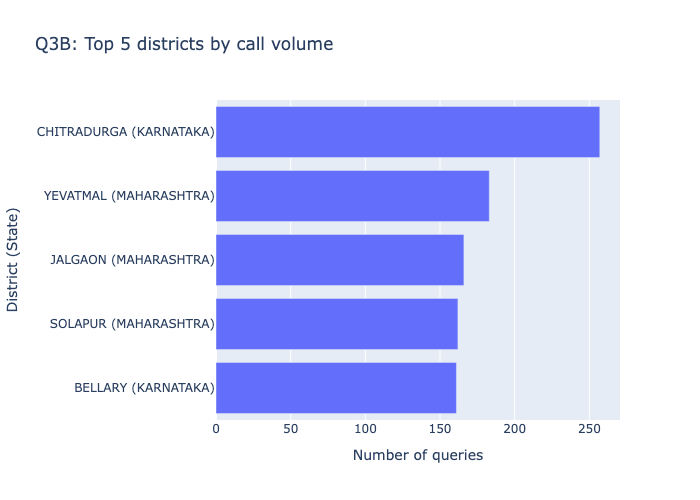

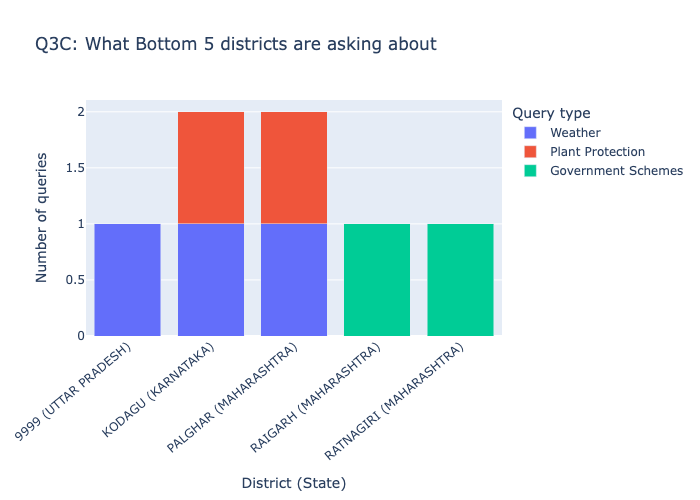

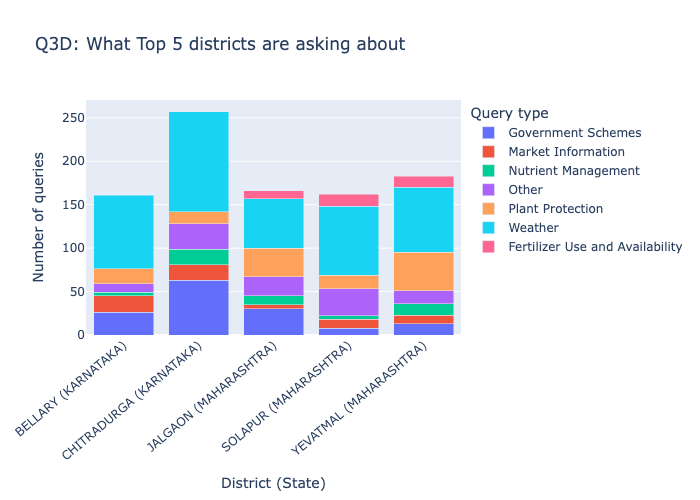

In [8]:
# Q3: Lowest-volume districts and what farmers are asking about (plus Top 5 comparison)
q3 = df.copy()
q3['StateName'] = q3['StateName'].astype(str).str.strip()
q3['DistrictName'] = q3['DistrictName'].astype(str).str.strip()
q3['QueryType_clean'] = q3['QueryType'].astype(str).str.strip()
q3['district_label'] = q3['DistrictName'] + ' (' + q3['StateName'] + ')'

district_counts = (
    q3.groupby(['StateName', 'DistrictName', 'district_label'])
    .size()
    .reset_index(name='count')
)

bottom5 = district_counts.nsmallest(5, 'count').copy()
top5 = district_counts.nlargest(5, 'count').copy()

print('Bottom 5 districts by call volume:')
display(bottom5[['district_label', 'count']])
print('\nTop 5 districts by call volume:')
display(top5[['district_label', 'count']])

fig_bottom = px.bar(
    bottom5.sort_values('count', ascending=True),
    x='count',
    y='district_label',
    orientation='h',
    title='Q3A: Bottom 5 districts by call volume',
    labels={'count': 'Number of queries', 'district_label': 'District (State)'},
)
fig_bottom.show()

fig_top = px.bar(
    top5.sort_values('count', ascending=True),
    x='count',
    y='district_label',
    orientation='h',
    title='Q3B: Top 5 districts by call volume',
    labels={'count': 'Number of queries', 'district_label': 'District (State)'},
)
fig_top.show()

# Topic mix within bottom and top districts
focus_labels = pd.concat([bottom5['district_label'], top5['district_label']]).unique().tolist()
focus = q3[q3['district_label'].isin(focus_labels)].copy()

mix = (
    focus.groupby(['district_label', 'QueryType_clean'])
    .size()
    .reset_index(name='count')
)

top_mix_types = mix.groupby('QueryType_clean')['count'].sum().sort_values(ascending=False).head(6).index.tolist()
mix['QueryType_grouped'] = mix['QueryType_clean'].where(mix['QueryType_clean'].isin(top_mix_types), 'Other')
mix2 = (
    mix.groupby(['district_label', 'QueryType_grouped'])['count']
    .sum()
    .reset_index()
)

bottom_labels = bottom5['district_label'].tolist()
top_labels = top5['district_label'].tolist()

fig_bottom_mix = px.bar(
    mix2[mix2['district_label'].isin(bottom_labels)],
    x='district_label',
    y='count',
    color='QueryType_grouped',
    barmode='stack',
    title='Q3C: What Bottom 5 districts are asking about',
    labels={'district_label': 'District (State)', 'count': 'Number of queries', 'QueryType_grouped': 'Query type'},
)
fig_bottom_mix.update_layout(xaxis_tickangle=-40)
fig_bottom_mix.show()

fig_top_mix = px.bar(
    mix2[mix2['district_label'].isin(top_labels)],
    x='district_label',
    y='count',
    color='QueryType_grouped',
    barmode='stack',
    title='Q3D: What Top 5 districts are asking about',
    labels={'district_label': 'District (State)', 'count': 'Number of queries', 'QueryType_grouped': 'Query type'},
)
fig_top_mix.update_layout(xaxis_tickangle=-40)
fig_top_mix.show()


### Q4. How does demand for Government Schemes information compare to Agronomy advice (Plant Protection, Fertilizer, Nutrient Management) across districts?

Are farmers calling more for bureaucratic help or technical farming help?

Top districts for Q4 comparison (Government Schemes vs Agronomy Advice):


,district_label,demand_group,count,pct
1,AGRA (UTTAR PRADESH),Agronomy Advice,7,25.925926
2,AGRA (UTTAR PRADESH),Government Schemes,20,74.074074
3,AHMADNAGAR (MAHARASHTRA),Agronomy Advice,33,76.744186
4,AHMADNAGAR (MAHARASHTRA),Government Schemes,10,23.255814
22,BADAUN (UTTAR PRADESH),Agronomy Advice,19,29.687500
23,BADAUN (UTTAR PRADESH),Government Schemes,45,70.312500
30,BALLIA (UTTAR PRADESH),Agronomy Advice,15,31.250000
31,BALLIA (UTTAR PRADESH),Government Schemes,33,68.750000
39,BAREILLY (UTTAR PRADESH),Agronomy Advice,15,45.454545
40,BAREILLY (UTTAR PRADESH),Government Schemes,18,54.545455


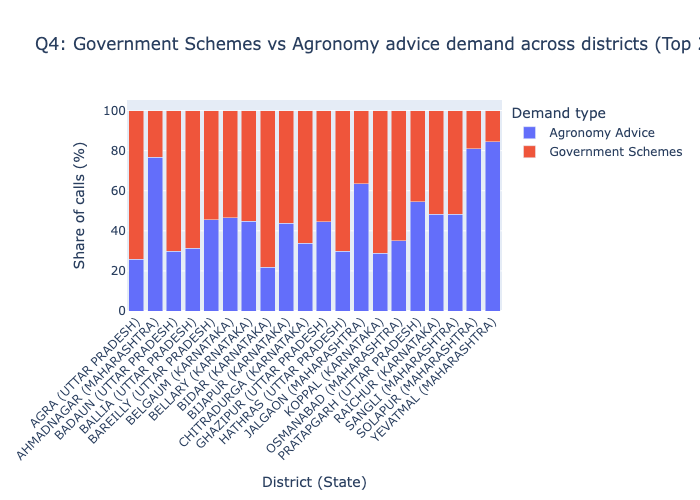

In [9]:
# Q4: Government Schemes vs Agronomy advice demand across districts
AGRONOMY_CORE = {
    'Plant Protection',
    'Fertilizer Use and Availability',
    'Nutrient Management',
}

q4 = df.copy()
q4['StateName'] = q4['StateName'].astype(str).str.strip()
q4['DistrictName'] = q4['DistrictName'].astype(str).str.strip()
q4['QueryType_clean'] = q4['QueryType'].astype(str).str.strip()
q4['district_label'] = q4['DistrictName'] + ' (' + q4['StateName'] + ')'

def demand_group(qt):
    if qt == 'Government Schemes':
        return 'Government Schemes'
    if qt in AGRONOMY_CORE:
        return 'Agronomy Advice'
    return 'Other'

q4['demand_group'] = q4['QueryType_clean'].apply(demand_group)
q4_focus = q4[q4['demand_group'].isin(['Government Schemes', 'Agronomy Advice'])].copy()

district_compare = (
    q4_focus.groupby(['district_label', 'demand_group'])
    .size()
    .reset_index(name='count')
)

combined_totals = district_compare.groupby('district_label')['count'].sum().sort_values(ascending=False)
top_districts = combined_totals.head(20).index.tolist()
district_compare_top = district_compare[district_compare['district_label'].isin(top_districts)].copy()

district_compare_top['pct'] = (
    100 * district_compare_top['count']
    / district_compare_top.groupby('district_label')['count'].transform('sum')
)

print('Top districts for Q4 comparison (Government Schemes vs Agronomy Advice):')
display(district_compare_top.sort_values(['district_label', 'demand_group']))

fig_q4 = px.bar(
    district_compare_top,
    x='district_label',
    y='pct',
    color='demand_group',
    barmode='stack',
    title='Q4: Government Schemes vs Agronomy advice demand across districts (Top 20 districts)',
    labels={'district_label': 'District (State)', 'pct': 'Share of calls (%)', 'demand_group': 'Demand type'},
)
fig_q4.update_layout(xaxis_tickangle=-45)
fig_q4.show()

---

## Section 4 — Visualization

Create at least one visualization that supports one of your analysis findings. Your chart should:

- Have a title that states the finding, not just the data (e.g., "Satisfaction scores drop sharply after age 40" not "Satisfaction by age")
- Have labeled axes
- Use a chart type appropriate for your data (bar for categorical comparison, scatter for relationships, line for trends over time)

Below the chart, explain in a markdown cell: why you chose this chart type, and what you want the reader to take away from it.

Top 10 crop-state combinations by technical-query volume:


,crop_state_label,count
14,Chillies (KARNATAKA),21
19,Cotton (Kapas) (KARNATAKA),22
83,Onion (MAHARASHTRA),23
1,Arecanut (KARNATAKA),24
95,Sugarcane (Noble Cane) (MAHARASHTRA),30
129,Mango (UTTAR PRADESH),34
151,Sugarcane (Noble Cane) (UTTAR PRADESH),38
93,Soybean (bhat) (MAHARASHTRA),49
138,Paddy (Dhan) (UTTAR PRADESH),89
64,Cotton (Kapas) (MAHARASHTRA),108


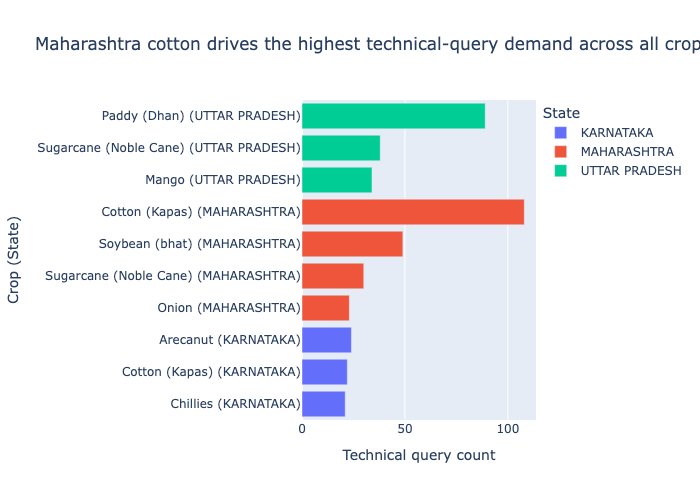

In [10]:
# Section 4 visualization: top crop-state combinations for technical demand
TECH_TYPES = {
    'Plant Protection',
    'Fertilizer Use and Availability',
    'Nutrient Management',
}

sec4 = df.copy()
sec4['StateName'] = sec4['StateName'].astype(str).str.strip()
sec4['QueryType_clean'] = sec4['QueryType'].astype(str).str.strip()
sec4['Crop_clean'] = sec4['Crop'].astype(str).str.strip()

sec4 = sec4[
    sec4['QueryType_clean'].isin(TECH_TYPES)
    & sec4['Crop_clean'].notna()
    & (sec4['Crop_clean'] != '')
    & (sec4['Crop_clean'].str.lower() != 'nan')
].copy()

crop_state_counts = (
    sec4.groupby(['StateName', 'Crop_clean'])
    .size()
    .reset_index(name='count')
)
crop_state_counts['crop_state_label'] = crop_state_counts['Crop_clean'] + ' (' + crop_state_counts['StateName'] + ')'

top10_crop_state = crop_state_counts.nlargest(10, 'count').sort_values('count', ascending=True)

print('Top 10 crop-state combinations by technical-query volume:')
display(top10_crop_state[['crop_state_label', 'count']])

fig_sec4 = px.bar(
    top10_crop_state,
    x='count',
    y='crop_state_label',
    color='StateName',
    orientation='h',
    title='Maharashtra cotton drives the highest technical-query demand across all crop-state combinations',
    labels={'count': 'Technical query count', 'crop_state_label': 'Crop (State)', 'StateName': 'State'},
)
fig_sec4.show()

### Why this chart and key takeaway

I used a ranked horizontal bar chart because it compares the top crop-state combinations by technical-query volume in one view. The chart shows that **Cotton (Maharashtra)** is the largest concentration of technical queries, which suggests KCC should prioritize Maharashtra cotton expertise in specialist staffing and advisory content.

---

## Section 5 — Conclusions

** What is the most important thing your analysis revealed?** 

 1. Certain issues are tagged under cultural practices which is not an accurate representation of what farmers are trying to ask. 
 
 2. Weather queries account for 20.4% of all calls — the single largest category, exceeding Plant Protection, Nutrient Management, and Fertilizer Use combined. KCC is designed as a human-staffed agronomic advisory service, so this volume is notable: weather forecasts do not require specialized expertise to relay. The gap between what the service is designed to provide and what farmers most frequently call about is worth examining from a design standpoint.


**What surprised Me**

The three states show meaningfully different query profiles. Uttar Pradesh farmers called primarily about Government Schemes across all three years, Maharashtra showed the most stable demand for technical agronomic support, and Karnataka fell somewhere between the two. Given that all three states use the same national service, the degree of variation in how farmers actually use it was unexpected.
    
- What would you investigate next if you had more time or data?

1. Across all three states, Weather queries declined between 2023 and 2024 while Government Schemes queries rose. This pattern is consistent enough to suggest farmers may be finding weather information through other channels while turning to KCC specifically for subsidy and program guidance. Linking call volume to district-level census data — farm size, crop type, literacy rates — would help test whether low-volume districts reflect limited awareness, connectivity constraints, or smaller farming populations.
    
2. I would also be interested in knowing if this conversation was helpful for the farmers, whether the call center represetative answered their questions with care and support or if the answers felt surface level solutions. 

3. What was the impact of the advice they received from this service on their daily lives and especially their farms. 

4. Whether existing government schemes  or subsidies been useful for farmers across these three states.


**What are the limitations of this analysis — what can't you conclude from this data?**

I am not being able to conclude if the responses farmers are receiving from the call center representatives is useful or not, or how are they implementing technical advice in their farms. Call counts show what farmers are asking about and how often. Resolution, satisfaction, and follow-up data would be needed to assess whether the service is meeting the needs it was designed for. The QueryType labels also show inconsistency — the Cultural Practices spike in Maharashtra in 2024 is likely attributable to reclassification rather than a genuine change in demand, which limits how much weight can be placed on category-level trends.


**Summary of findings:**  

Weather queries dominate call volume across all three states, accounting for 20.4% of all calls — more than any technical agronomic category. Across the 2022–2024 period, Weather queries declined while Government Schemes queries rose sharply, suggesting a gradual shift in how farmers are using the service. The three states show distinct query profiles: Uttar Pradesh relies on KCC primarily for scheme guidance, Maharashtra shows the strongest demand for technical crop support, and Karnataka shows the sharpest growth in Government Schemes over time. Cotton in Maharashtra generates the highest concentration of technical queries of any crop-state combination in the dataset. QueryType labels show some inconsistency across states and years, which affects how confidently category-level trends can be interpreted.
